In [4]:
import numpy as numpy
import pandas as pd

In [5]:
columns = ['Letter'] + [f"features{i}" for i in range(16)]

In [6]:
df=pd.read_csv('letter-recognition.data',names=columns)

In [7]:
df.head()

,Letter,features0,features1,features2,features3,features4,features5,features6,features7,features8,features9,features10,features11,features12,features13,features14,features15
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [8]:
df.isnull().sum()

Letter        0
features0     0
features1     0
features2     0
features3     0
features4     0
features5     0
features6     0
features7     0
features8     0
features9     0
features10    0
features11    0
features12    0
features13    0
features14    0
features15    0
dtype: int64

In [9]:
x=df.drop('Letter',axis=1)
y=df['Letter']

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
encoder = LabelEncoder()

In [12]:
y_encoded = encoder.fit_transform(y)

In [13]:
from tensorflow.keras.utils import to_categorical
y_catogorical = to_categorical(y_encoded)

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y_catogorical,random_state=42,test_size=0.20)

In [16]:
print("Classes :",encoder.classes_)

Classes : ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
sc = StandardScaler()

In [19]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [20]:
from keras.models import Sequential
from keras.layers import Dense

In [21]:
model = Sequential()

In [22]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(16,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(26, activation='softmax'))

c:\Users\rrbag\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,122 (47.35 KB)

 Trainable params: 12,122 (47.35 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(x_train,y_train,epochs=45,validation_split=0.2,verbose=1)

Epoch 1/45
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5829 - loss: 1.5497 - val_accuracy: 0.7397 - val_loss: 0.9104
Epoch 2/45
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7854 - loss: 0.7406 - val_accuracy: 0.7981 - val_loss: 0.6825
Epoch 3/45
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8369 - loss: 0.5662 - val_accuracy: 0.8484 - val_loss: 0.5240
Epoch 4/45
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8630 - loss: 0.4641 - val_accuracy: 0.8734 - val_loss: 0.4457
Epoch 5/45
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8866 - loss: 0.3932 - val_accuracy: 0.8809 - val_loss: 0.3945
Epoch 6/45
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9016 - loss: 0.3359 - val_accuracy: 0.8925 - val_loss: 0.3402
Epoch 7/45
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9128 - loss: 0.2960 - val_accuracy: 0.8978 - val_loss: 0.3212
Epoch 8/45
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9192 - loss: 0.2643 - val_accuracy: 0.

In [26]:
y_prob = model.predict(x_test)
y_pred = numpy.argmax(y_prob, axis=1)
y_true = numpy.argmax(y_test, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step


In [27]:
from sklearn.metrics import accuracy_score, classification_report

print('Test Accuracy:', accuracy_score(y_true, y_pred))
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

Test Accuracy: 0.9545

Classification Report:
              precision    recall  f1-score   support

           A       0.95      0.99      0.97       149
           B       0.95      0.95      0.95       153
           C       0.96      0.95      0.95       137
           D       0.96      0.94      0.95       156
           E       0.92      0.95      0.94       141
           F       0.95      0.94      0.95       140
           G       0.97      0.89      0.93       160
           H       0.91      0.88      0.90       144
           I       0.95      0.97      0.96       146
           J       0.98      0.95      0.96       149
           K       0.88      0.95      0.91       130
           L       0.94      0.98      0.96       155
           M       0.99      0.96      0.98       168
           N       0.98      0.93      0.95       151
           O       0.95      0.96      0.95       145
           P       0.97      0.97      0.97       173
           Q       0.95      0.98  

In [28]:
import matplotlib.pyplot as plt

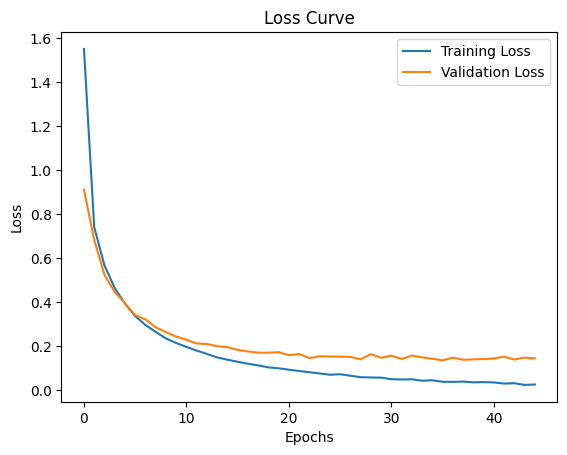

In [29]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()